# Tugas 2 Analisis Numerik: Menghitung Volume Kedua Lambung Perahu Katamaran

| | |
|---|---|
| **Nama** | Rafinda Mutiara Nurfitriati |
| **NPM** | 25083010012 |
| **Kelas** | A |
| **Program Studi** | Sains Data |
| **Mata Kuliah** | Analisis Numerik |
| **Soal** | [perahu.pdf (GitHub)](https://github.com/jendralhxr/metnummatdis/blob/main/perahu.pdf) |
| **Sumber gambar** | [Desain dan Konstruksi Perahu Katamaran Fiberglass untuk Wisata Pancing (ResearchGate)](https://www.researchgate.net/publication/342077926_Desain_dan_Konstruksi_Perahu_Katamaran_Fiberglass_untuk_Wisata_Pancing) |
| **Repositori GitHub** | [25083010012-RafindaMutiaraNurfitriati/Analisis-Breakeven-Donat](https://github.com/25083010012-RafindaMutiaraNurfitriati/Analisis-Breakeven-Donat) |

---

## 1. Deskripsi Tugas

Tugas ini meminta saya **menghitung volume kedua lambung** perahu katamaran dari gambar teknik (tampak atas dan tampak samping) yang dilengkapi grid hijau putus-putus. Ketentuan dari soal dan arahan dosen yang saya pakai:

1. Satu garis grid putus-putus: satu *dash* + satu bagian kosong = 5 + 5 = **10 cm**.
2. Satu kotak grid berisi 4,5 periode *dash-kosong*, sehingga **1 kotak = 45 cm** (arahan dosen).
3. Lantai kapal **datar** (tanpa keel), jadi penampang depan lambung berupa **persegi panjang**.
4. Volume ***reserve buoyancy* tidak dihitung**, sehingga batas lambung yang dihitung adalah dua garis sekat reserve buoyancy (buritan dan haluan).
5. Jumlah segmen perhitungan diperbanyak (minimal 10 segmen). Pada tugas ini saya memakai **32 segmen** sebagai perhitungan utama dan membandingkannya dengan 10 segmen serta jumlah segmen lain.
6. Yang dinilai adalah **proses** pengerjaan, bukan kebenaran yang mutlak. Karena itu setiap asumsi, langkah hitung, dan sumber galat saya tuliskan secara terbuka.

## 2. Dasar Perhitungan

Karena lantai datar, penampang melintang di posisi $x$ (diukur dari sekat buritan ke arah haluan) adalah persegi panjang dengan

- $w(x)$ = **lebar** lambung (dibaca dari tampak atas),
- $h(x)$ = **tinggi** lambung dari garis geladak sampai dasar (dibaca dari tampak samping).

Luas penampangnya

$$A(x) = w(x)\,h(x)$$

dan volume satu lambung adalah integral luas penampang sepanjang lambung di antara dua sekat *reserve buoyancy*

$$V = \int_{0}^{L} w(x)\,h(x)\,dx .$$

Fungsi $w(x)$ dan $h(x)$ hanya tersedia dari gambar, bukan rumus, sehingga integralnya dihitung **secara numerik** dengan dua metode.

**Aturan Trapesium** (jarak titik boleh berbeda):

$$V \approx \sum_{i=0}^{n-1}\frac{A_i + A_{i+1}}{2}\,(x_{i+1}-x_i)$$

**Aturan Simpson 1/3** (jarak titik seragam $\Delta x$, jumlah segmen $n$ genap):

$$V \approx \frac{\Delta x}{3}\Big[A_0 + 4\sum_{i\ \text{ganjil}}A_i + 2\sum_{i\ \text{genap}}A_i + A_n\Big]$$

Galat Trapesium sebanding dengan $\Delta x^2$, sedangkan galat Simpson sebanding dengan $\Delta x^4$ (untuk fungsi yang cukup mulus). Jadi Simpson biasanya lebih teliti pada jumlah segmen yang sama.

## 3. Penentuan Skala Gambar

PDF soal saya ubah menjadi gambar dengan resolusi 200 dpi. Pada gambar tersebut jarak antar garis grid hijau saya ukur dari posisi piksel garisnya (hasil rata-rata jarak 20 kotak ≈ 71,18 piksel). Menurut arahan dosen, satu kotak ini bernilai **45 cm**, sehingga

$$1\ \text{piksel} = \frac{45\ \text{cm}}{71{,}175\ \text{piksel}} \approx 0{,}632\ \text{cm}.$$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid as sp_trapezoid, simpson as sp_simpson

np.set_printoptions(precision=3, suppress=True)
pd.options.display.float_format = "{:,.2f}".format
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

In [2]:
# ---- Skala gambar ----
DASH_CM  = 10.0          # 1 dash + 1 bagian kosong = 5 + 5 cm
KOTAK_CM = 45.0          # 1 kotak grid (arahan dosen)
DPI      = 200           # resolusi rasterisasi PDF
GRID_PX  = 71.175        # jarak antar garis grid hasil pengukuran piksel (px)
CM_PER_PX = KOTAK_CM / GRID_PX

DASH_PX = 6.0 / 72 * DPI                  # satu periode dash = 6 pt (pada 200 dpi)
periode_per_kotak_ukur = GRID_PX / DASH_PX

print(f"Skala                      : 1 px = {CM_PER_PX:.4f} cm")
print(f"1 kotak = {KOTAK_CM:.0f} cm  ->  {KOTAK_CM/DASH_CM:.1f} periode dash-kosong (arahan dosen)")
print(f"Hasil ukur piksel          : {periode_per_kotak_ukur:.2f} periode dash per kotak")
print(f"Selisih ukur vs arahan     : {100*(KOTAK_CM/DASH_CM - periode_per_kotak_ukur)/(KOTAK_CM/DASH_CM):.1f} %")

Skala                      : 1 px = 0.6322 cm
1 kotak = 45 cm  ->  4.5 periode dash-kosong (arahan dosen)
Hasil ukur piksel          : 4.27 periode dash per kotak
Selisih ukur vs arahan     : 5.1 %


Hasil ukur piksel (4,27 periode per kotak) sedikit berbeda dari arahan dosen (4,5 periode). Selisih sekitar 5% ini mungkin berasal dari ketebalan garis dan pembulatan piksel, jadi saya **mengikuti arahan dosen (1 kotak = 45 cm)** sebagai skala resmi. Dampak selisih ini terhadap volume saya bahas pada bagian 10.

## 4. Pengambilan Data dari Gambar (Digitasi)

Supaya tidak sekadar menebak dengan mata, data diambil dengan analisis piksel:

1. Piksel hijau (grid) dibuang, hanya piksel **abu-abu gelap** (garis kontur lambung) yang dipakai.
2. **Lebar $w(x)$** dibaca dari tampak atas. Untuk tiap kolom piksel dicari tepi atas dan tepi bawah kontur, lalu jaraknya ke sumbu simetri lambung diambil (median dari 4 tepi: 2 lambung × 2 sisi). Bagian yang tertutup balok melintang atau penyangga **dibuang** dari estimasi.
3. **Tinggi $h(x)$** dibaca dari tampak samping: dari garis geladak sampai tepi bawah kontur, dengan batas dasar yang datar.
4. **Batas integrasi** adalah garis sekat *reserve buoyancy* kiri (garis lengkung dekat buritan) dan kanan (garis lurus dekat haluan). Bagian di luar kedua sekat tidak dihitung.
5. Profil diambil pada **160 titik halus** di antara dua sekat. Titik halus ini dipakai sebagai bank data, lalu perhitungan utama memakai sebagian titiknya (32 segmen) dan sisanya untuk uji jumlah segmen.

Kode digitasi saya sertakan agar prosesnya bisa direproduksi. Secara bawaan sel ini **dinonaktifkan** (`RUN_DIGITIZATION = False`) agar notebook bisa dijalankan tanpa file PDF dan tanpa `poppler`. Hasil digitasi sudah disimpan pada bagian 5.

In [3]:
RUN_DIGITIZATION = False     # True bila "perahu.pdf" ada di folder ini dan poppler-utils (pdftoppm) terpasang
PDF_PATH = "perahu.pdf"

def digitasi_lambung(png_path, n_segmen=160, cm_per_px=CM_PER_PX):
    """Mengembalikan (L_cm, w_cm, h_cm): panjang antar sekat dan profil lebar/tinggi pada n_segmen+1 titik."""
    import warnings
    from PIL import Image
    warnings.filterwarnings("ignore", category=RuntimeWarning)

    im = np.array(Image.open(png_path).convert("RGB")).astype(int)
    s = im.shape[1] / 1456.0                      # koordinat acuan diukur pada tampilan lebar 1456 px
    dark = (im.max(2) < 175) & (abs(im[:, :, 0] - im[:, :, 1]) < 25) & (abs(im[:, :, 1] - im[:, :, 2]) < 25)
    D = lambda v: v * s

    def top(x, a, b):
        ys = np.where(dark[int(D(a)):int(D(b)), x])[0]
        return ys.min() + int(D(a)) if len(ys) else np.nan
    def bot(x, a, b):
        ys = np.where(dark[int(D(a)):int(D(b)), x])[0]
        return ys.max() + int(D(a)) if len(ys) else np.nan

    x_sekat_kiri, x_sekat_kanan = D(130.1), D(888.1)
    y_deck, y_dasar = D(642.5), D(765.7)

    # sumbu simetri tiap lambung dari zona tengah yang bersih
    zona = [int(D(v)) for v in range(300, 650, 10)]
    c_atas  = np.nanmedian([(top(x, 89, 200) + bot(x, 89, 200)) / 2 for x in zona])
    c_bawah = np.nanmedian([(top(x, 425, 540) + bot(x, 425, 540)) / 2 for x in zona])

    def setengah_lebar(xp):
        xd = xp / s
        balok = (203 <= xd <= 221) or (722 <= xd <= 741)       # balok melintang
        brace = (203 <= xd <= 268) or (668 <= xd <= 742)       # penyangga
        label = (60 <= xd <= 165)                              # tulisan "Reserve buoyancy"
        est = []
        if not balok and not label: est.append(c_atas - top(xp, 89, 200))
        if not balok:
            if not brace: est.append(c_bawah - top(xp, 425, 540))
            est.append(bot(xp, 425, 540) - c_bawah)
        if not balok and not brace: est.append(bot(xp, 89, 200) - c_atas)
        est = [e for e in est if e == e and e > 0]
        return np.median(est) if est else np.nan

    titik = np.linspace(x_sekat_kiri, x_sekat_kanan, n_segmen + 1)
    w_out, h_out = [], []
    for xp in titik:
        xi = int(round(xp))
        hw = np.nanmedian([setengah_lebar(xi + d) for d in range(-3, 4)])
        bw = np.nanmedian([bot(xi + d, 640, 772) for d in range(-3, 4)])
        bw = min(bw, y_dasar)
        w_out.append(2 * hw * cm_per_px)
        h_out.append((bw - y_deck) * cm_per_px)
    return (x_sekat_kanan - x_sekat_kiri) * cm_per_px, np.array(w_out), np.array(h_out)

if RUN_DIGITIZATION:
    import subprocess, glob
    subprocess.run(["pdftoppm", "-png", "-r", str(DPI), "-f", "1", "-l", "1", PDF_PATH, "raster"], check=True)
    png = sorted(glob.glob("raster*.png"))[0]
    L_hasil, w_hasil, h_hasil = digitasi_lambung(png)
    print(f"Digitasi selesai: L = {L_hasil:.1f} cm, {len(w_hasil)} titik")
else:
    print("Digitasi dilewati; memakai data hasil digitasi yang tersimpan pada bagian 5.")

Digitasi dilewati; memakai data hasil digitasi yang tersimpan pada bagian 5.


## 5. Data Hasil Digitasi

Koordinat $x$ diukur dari **sekat buritan** ($x = 0$) sampai **sekat haluan** ($x = L$). Nilai `NaN` pada lebar berarti tepi lambung di posisi itu tertutup balok melintang atau penyangga sehingga tidak bisa diukur langsung.

In [4]:
# Panjang lambung di antara dua sekat reserve buoyancy (cm)
L = 725.77
N_FINE = 160                                  # jumlah segmen pada bank data halus
x_fine = np.linspace(0.0, L, N_FINE + 1)      # posisi seragam sepanjang lambung (cm)

# Lebar lambung w(x), dari tampak atas (cm). NaN = tertutup balok/penyangga
w_fine_mentah = np.array([
    78.40, 79.66, 80.93, 80.93, 82.19, 83.46, 83.46, 84.72,
    85.35, 85.99, 86.62, 87.25, 87.88, 88.51, 89.15, 89.78,
    np.nan, np.nan, np.nan, 91.68, 92.31, 92.31, 92.94, 92.94,
    93.57, 93.57, 93.57, 94.20, 94.84, 94.84, 94.84, 94.84,
    94.84, 94.84, 95.47, 95.47, 95.47, 96.10, 96.10, 96.10,
    96.10, 96.10, 96.10, 96.10, 96.10, 96.10, 96.10, 96.10,
    96.10, 96.10, 96.10, 96.10, 96.10, 96.10, 96.10, 96.10,
    96.10, 96.10, 96.10, 96.10, 96.10, 96.10, 96.10, 96.10,
    96.10, 96.10, 96.10, 96.10, 96.10, 96.10, 96.10, 96.10,
    96.10, 96.10, 96.10, 96.10, 96.10, 96.10, 96.10, 96.10,
    96.10, 96.10, 96.10, 96.10, 96.10, 96.10, 96.10, 96.10,
    96.10, 96.10, 96.10, 96.10, 96.10, 96.10, 96.10, 96.10,
    96.10, 96.10, 96.10, 96.10, 96.10, 96.10, 96.10, 96.10,
    96.10, 96.10, 96.10, 96.10, 96.10, 96.10, 96.10, 95.47,
    95.47, 95.47, 96.10, 95.47, 94.84, 94.84, 94.84, 94.84,
    94.84, 94.20, 94.20, 93.57, 92.94, 92.94, np.nan, np.nan,
    np.nan, 90.73, 89.78, 89.78, 88.51, 88.51, 87.25, 87.25,
    85.99, 85.99, 84.72, 84.09, 83.46, 82.19, 80.93, 80.93,
    79.66, 78.40, 77.77, 76.50, 75.87, 74.60, 73.34, 72.08,
    70.81, 69.55, 68.28, 67.02, 65.75, 64.49, 61.96, 60.70,
    59.43,
])

# Tinggi lambung h(x), dari garis geladak ke dasar datar, tampak samping (cm)
h_fine = np.array([
    85.34, 87.24, 88.50, 90.40, 92.30, 94.19, 96.09, 97.36,
    99.25, 100.52, 101.78, 103.68, 104.94, 106.21, 107.47, 108.74,
    110.00, 111.26, 112.53, 113.16, 114.43, 115.69, 116.32, 117.59,
    117.96, 117.96, 117.96, 117.96, 117.96, 117.96, 117.96, 117.96,
    117.96, 117.96, 117.96, 117.96, 117.96, 117.96, 117.96, 117.96,
    117.96, 117.96, 117.96, 117.96, 117.96, 117.96, 117.96, 117.96,
    117.96, 117.96, 117.96, 117.96, 117.96, 117.96, 117.96, 117.96,
    117.96, 117.96, 117.96, 117.96, 117.96, 117.96, 117.96, 117.96,
    117.96, 117.96, 117.96, 117.96, 117.96, 117.96, 117.96, 117.96,
    117.96, 117.96, 117.96, 117.96, 117.96, 117.96, 117.96, 117.96,
    117.96, 117.96, 117.96, 117.96, 117.96, 117.96, 117.96, 117.96,
    117.96, 117.96, 117.96, 117.96, 117.59, 117.59, 117.59, 117.59,
    117.59, 117.59, 117.59, 117.59, 117.59, 117.59, 117.59, 117.59,
    117.59, 117.59, 117.59, 117.59, 117.59, 117.59, 117.59, 117.59,
    117.59, 117.59, 117.59, 117.59, 117.59, 117.59, 117.59, 117.59,
    117.59, 117.59, 117.59, 117.59, 117.59, 117.59, 117.59, 117.59,
    117.59, 117.59, 117.59, 117.59, 117.59, 117.59, 117.59, 117.59,
    117.59, 117.59, 117.59, 117.59, 117.59, 117.59, 117.59, 117.59,
    117.59, 117.59, 117.59, 117.59, 117.59, 117.59, 117.59, 117.59,
    117.59, 117.59, 117.59, 117.59, 117.59, 117.59, 117.59, 117.59,
    117.59,
])

print(f"Panjang lambung antar sekat : L = {L:.1f} cm = {L/100:.2f} m")
print(f"Jumlah titik bank data      : {len(x_fine)}")
print(f"Titik lebar yang hilang     : {int(np.isnan(w_fine_mentah).sum())} titik pada x = {np.round(x_fine[np.isnan(w_fine_mentah)], 1)} cm")

Panjang lambung antar sekat : L = 725.8 cm = 7.26 m
Jumlah titik bank data      : 161
Titik lebar yang hilang     : 6 titik pada x = [ 72.6  77.1  81.6 571.5 576.1 580.6] cm


### 5.1 Penanganan Data yang Hilang

Titik lebar yang tertutup balok jumlahnya sedikit dan kontur lambung di daerah itu mulus (tidak ada perubahan mendadak). Karena itu nilainya saya isi dengan **interpolasi linear** dari titik valid di kiri dan kanannya.

In [5]:
valid = ~np.isnan(w_fine_mentah)
w_fine = np.interp(x_fine, x_fine[valid], w_fine_mentah[valid])

hilang = ~valid
print("Titik yang diisi dengan interpolasi linear:")
for xi, wi in zip(x_fine[hilang], w_fine[hilang]):
    print(f"   x = {xi:6.1f} cm  ->  w = {wi:5.1f} cm")
print(f"\nLebar maksimum  : {w_fine.max():.1f} cm")
print(f"Tinggi maksimum : {h_fine.max():.1f} cm")

Titik yang diisi dengan interpolasi linear:
   x =   72.6 cm  ->  w =  90.3 cm
   x =   77.1 cm  ->  w =  90.7 cm
   x =   81.6 cm  ->  w =  91.2 cm
   x =  571.5 cm  ->  w =  92.4 cm
   x =  576.1 cm  ->  w =  91.8 cm
   x =  580.6 cm  ->  w =  91.3 cm

Lebar maksimum  : 96.1 cm
Tinggi maksimum : 118.0 cm


## 6. Pemilihan Jumlah Segmen dan Tabel Data

Perhitungan utama memakai **$n = 32$ segmen** (33 titik) dengan jarak titik seragam $\Delta x = L/n$. Jumlah ini lebih dari 10 segmen dan genap, sehingga bisa dipakai oleh Trapesium maupun Simpson 1/3. Luas penampang di tiap titik dihitung dengan $A_i = w_i \times h_i$.

In [6]:
N = 32
langkah = N_FINE // N                     # ambil tiap 5 titik dari bank data halus
idx = np.arange(0, N_FINE + 1, langkah)

x = x_fine[idx]
w = w_fine[idx]
h = h_fine[idx]
A = w * h                                 # luas penampang tiap titik (cm^2)
dx = np.diff(x)

print(f"Jumlah segmen n = {N}  ({len(x)} titik)")
print(f"Lebar segmen dx = {L:.2f} / {N} = {L/N:.3f} cm  (min {dx.min():.3f}, maks {dx.max():.3f})")
print()
tabel = pd.DataFrame({"i": np.arange(len(x)), "x (cm)": x, "lebar w (cm)": w, "tinggi h (cm)": h, "A = w x h (cm2)": A})
print(tabel.to_string(index=False))

Jumlah segmen n = 32  (33 titik)
Lebar segmen dx = 725.77 / 32 = 22.680 cm  (min 22.680, maks 22.680)

 i  x (cm)  lebar w (cm)  tinggi h (cm)  A = w x h (cm2)
 0    0.00         78.40          85.34         6,690.66
 1   22.68         83.46          94.19         7,861.10
 2   45.36         86.62         101.78         8,816.18
 3   68.04         89.78         108.74         9,762.68
 4   90.72         92.31         114.43        10,563.03
 5  113.40         93.57         117.96        11,037.52
 6  136.08         94.84         117.96        11,187.33
 7  158.76         95.47         117.96        11,261.64
 8  181.44         96.10         117.96        11,335.96
 9  204.12         96.10         117.96        11,335.96
10  226.80         96.10         117.96        11,335.96
11  249.48         96.10         117.96        11,335.96
12  272.16         96.10         117.96        11,335.96
13  294.84         96.10         117.96        11,335.96
14  317.52         96.10         117.96   

Contoh perhitungan luas penampang pada titik pertama dan titik di tengah lambung:

In [7]:
for i in [0, N // 2]:
    print(f"A_{i} = w x h = {w[i]:.2f} x {h[i]:.2f} = {A[i]:.2f} cm^2   (x = {x[i]:.1f} cm)")

A_0 = w x h = 78.40 x 85.34 = 6690.66 cm^2   (x = 0.0 cm)
A_16 = w x h = 96.10 x 117.96 = 11335.96 cm^2   (x = 362.9 cm)


## 7. Implementasi Metode Numerik

Dua fungsi saya tulis sendiri (tanpa library integrasi) supaya prosesnya terlihat. Keduanya diuji dulu pada integral yang jawabannya diketahui, yaitu $\int_0^3 x^2\,dx = 9$.

In [8]:
def trapezoid(xv, yv):
    """Aturan trapesium komposit (jarak boleh tidak seragam)."""
    xv, yv = np.asarray(xv, float), np.asarray(yv, float)
    return float(np.sum(np.diff(xv) * (yv[1:] + yv[:-1]) / 2.0))

def simpson(xv, yv):
    """Aturan Simpson 1/3 komposit (jarak seragam, jumlah segmen genap)."""
    xv, yv = np.asarray(xv, float), np.asarray(yv, float)
    n = len(xv) - 1
    if n % 2 != 0:
        raise ValueError("Simpson 1/3 butuh jumlah segmen genap.")
    if not np.allclose(np.diff(xv), (xv[-1] - xv[0]) / n):
        raise ValueError("Simpson 1/3 butuh jarak titik seragam.")
    d = (xv[-1] - xv[0]) / n
    return float(d / 3.0 * (yv[0] + yv[-1] + 4.0 * yv[1:-1:2].sum() + 2.0 * yv[2:-1:2].sum()))

# Uji: integral x^2 pada [0, 3] (eksak = 9)
xt = np.linspace(0, 3, 7)
print("Uji integral x^2 pada [0, 3] (eksak = 9):")
print("   Trapesium :", trapezoid(xt, xt**2))
print("   Simpson   :", simpson(xt, xt**2))

Uji integral x^2 pada [0, 3] (eksak = 9):
   Trapesium : 9.125
   Simpson   : 9.0


## 8. Perhitungan Metode Trapesium (n = 32)

Untuk setiap segmen, volume potongan dihitung dari luas rata-rata kedua ujungnya dikali lebar segmen:

$$V_i = \frac{A_i + A_{i+1}}{2}\,\Delta x$$

lalu seluruh $V_i$ dijumlahkan.

In [9]:
A_rata = (A[:-1] + A[1:]) / 2
V_seg = A_rata * dx
V_kum = np.cumsum(V_seg)

tab_trap = pd.DataFrame({
    "Segmen": np.arange(1, N + 1),
    "x_i (cm)": x[:-1],
    "x_i+1 (cm)": x[1:],
    "A_i (cm2)": A[:-1],
    "A_i+1 (cm2)": A[1:],
    "A rata2 (cm2)": A_rata,
    "dx (cm)": dx,
    "V_i (cm3)": V_seg,
    "V kumulatif (cm3)": V_kum,
})
print(tab_trap.to_string(index=False))

 Segmen  x_i (cm)  x_i+1 (cm)  A_i (cm2)  A_i+1 (cm2)  A rata2 (cm2)  dx (cm)  V_i (cm3)  V kumulatif (cm3)
      1      0.00       22.68   6,690.66     7,861.10       7,275.88    22.68 165,019.16         165,019.16
      2     22.68       45.36   7,861.10     8,816.18       8,338.64    22.68 189,122.97         354,142.13
      3     45.36       68.04   8,816.18     9,762.68       9,289.43    22.68 210,687.18         564,829.31
      4     68.04       90.72   9,762.68    10,563.03      10,162.86    22.68 230,496.73         795,326.05
      5     90.72      113.40  10,563.03    11,037.52      10,800.28    22.68 244,953.62       1,040,279.66
      6    113.40      136.08  11,037.52    11,187.33      11,112.42    22.68 252,033.20       1,292,312.86
      7    136.08      158.76  11,187.33    11,261.64      11,224.48    22.68 254,574.80       1,546,887.66
      8    158.76      181.44  11,261.64    11,335.96      11,298.80    22.68 256,260.28       1,803,147.95
      9    181.44      204.1

**Catatan satuan:** semua kolom volume pada tabel di atas (termasuk volume kumulatif) berada dalam **cm³**, sedangkan luas penampang dalam cm² dan panjang dalam cm. Konversi ke m³ (dibagi 1.000.000) dan liter (dibagi 1.000) baru dilakukan pada hasil akhir.

Tiga segmen pertama saya tuliskan langkah hitungnya agar bisa dicek secara manual:

In [10]:
for i in range(3):
    print(f"Segmen {i+1}: V = (({A[i]:,.2f} + {A[i+1]:,.2f}) / 2) x {dx[i]:.3f}")
    print(f"           V = {A_rata[i]:,.2f} x {dx[i]:.3f} = {V_seg[i]:,.2f} cm^3\n")

Segmen 1: V = ((6,690.66 + 7,861.10) / 2) x 22.680
           V = 7,275.88 x 22.680 = 165,019.16 cm^3

Segmen 2: V = ((7,861.10 + 8,816.18) / 2) x 22.680
           V = 8,338.64 x 22.680 = 189,122.97 cm^3

Segmen 3: V = ((8,816.18 + 9,762.68) / 2) x 22.680
           V = 9,289.43 x 22.680 = 210,687.18 cm^3



In [11]:
V_trap = float(V_seg.sum())

print("Jumlah volume semua segmen (satu lambung):")
print(f"   V_trapesium = {V_trap:,.2f} cm^3")
print(f"               = {V_trap/1e6:.4f} m^3")
print(f"               = {V_trap/1e3:,.1f} liter")

# Pemeriksaan: rumus trapesium bentuk lain, dx/2 [A_0 + 2 (A_1 + ... + A_n-1) + A_n]
V_cek = dx.mean() / 2 * (A[0] + 2 * A[1:-1].sum() + A[-1])
print(f"\nCek dengan rumus dx/2 [A0 + 2 sum(A_tengah) + An] = {V_cek:,.2f} cm^3 -> cocok: {np.isclose(V_trap, V_cek)}")

Jumlah volume semua segmen (satu lambung):
   V_trapesium = 7,640,735.96 cm^3
               = 7.6407 m^3
               = 7,640.7 liter

Cek dengan rumus dx/2 [A0 + 2 sum(A_tengah) + An] = 7,640,735.96 cm^3 -> cocok: True


## 9. Perhitungan Metode Simpson 1/3 (n = 32)

Simpson 1/3 memerlukan $n$ genap dan jarak titik seragam. Keduanya terpenuhi ($n = 32$). Titik berindeks ganjil dikali 4 dan titik tengah berindeks genap dikali 2.

In [12]:
dx_s = L / N
A0, An = A[0], A[-1]
jum_ganjil = A[1:-1:2].sum()       # A_1 + A_3 + ... + A_(n-1)
jum_genap = A[2:-1:2].sum()        # A_2 + A_4 + ... + A_(n-2)

print(f"dx                      = {dx_s:.4f} cm")
print(f"A_0                     = {A0:,.2f} cm^2")
print(f"A_n                     = {An:,.2f} cm^2")
print(f"Jumlah A indeks ganjil  = {jum_ganjil:,.2f} cm^2   ({len(A[1:-1:2])} suku)")
print(f"Jumlah A indeks genap   = {jum_genap:,.2f} cm^2   ({len(A[2:-1:2])} suku)")

kurung = A0 + 4 * jum_ganjil + 2 * jum_genap + An
V_simp = dx_s / 3 * kurung
print(f"\nV = (dx/3) [A0 + 4 x ganjil + 2 x genap + An]")
print(f"  = ({dx_s:.4f}/3) x [{A0:,.2f} + 4 x {jum_ganjil:,.2f} + 2 x {jum_genap:,.2f} + {An:,.2f}]")
print(f"  = ({dx_s:.4f}/3) x {kurung:,.2f}")
print(f"  = {V_simp:,.2f} cm^3 = {V_simp/1e6:.4f} m^3 = {V_simp/1e3:,.1f} liter")
print(f"\nCocok dengan fungsi simpson() buatan sendiri? {np.isclose(V_simp, simpson(x, A))}")

dx                      = 22.6803 cm
A_0                     = 6,690.66 cm^2
A_n                     = 6,988.37 cm^2
Jumlah A indeks ganjil  = 168,718.31 cm^2   (16 suku)
Jumlah A indeks genap   = 161,330.66 cm^2   (15 suku)

V = (dx/3) [A0 + 4 x ganjil + 2 x genap + An]
  = (22.6803/3) x [6,690.66 + 4 x 168,718.31 + 2 x 161,330.66 + 6,988.37]
  = (22.6803/3) x 1,011,213.57
  = 7,644,879.94 cm^3 = 7.6449 m^3 = 7,644.9 liter

Cocok dengan fungsi simpson() buatan sendiri? True


### 9.1 Pemeriksaan Silang dengan Fungsi Bawaan SciPy

In [13]:
V_sp_trap = sp_trapezoid(A, x)
V_sp_simp = sp_simpson(A, x=x)

pembanding = pd.DataFrame({
    "Metode": ["Trapesium (buatan sendiri)", "Trapesium (SciPy)", "Simpson 1/3 (buatan sendiri)", "Simpson 1/3 (SciPy)"],
    "V satu lambung (cm3)": [V_trap, V_sp_trap, V_simp, V_sp_simp],
    "V satu lambung (m3)": [V_trap/1e6, V_sp_trap/1e6, V_simp/1e6, V_sp_simp/1e6],
})
pd.options.display.float_format = "{:,.4f}".format
print(pembanding.to_string(index=False))
pd.options.display.float_format = "{:,.2f}".format

print(f"\nSelisih Simpson - Trapesium = {V_simp - V_trap:,.1f} cm^3 ({100*(V_simp - V_trap)/V_trap:.3f} %)")

                      Metode  V satu lambung (cm3)  V satu lambung (m3)
  Trapesium (buatan sendiri)        7,640,735.9621               7.6407
           Trapesium (SciPy)        7,640,735.9621               7.6407
Simpson 1/3 (buatan sendiri)        7,644,879.9444               7.6449
         Simpson 1/3 (SciPy)        7,644,879.9444               7.6449

Selisih Simpson - Trapesium = 4,144.0 cm^3 (0.054 %)


## 10. Visualisasi

### 10.1 Profil Lambung

Garis penuh adalah bank data halus (160 segmen) dan titik-titik adalah 33 titik yang dipakai pada perhitungan utama. Titik merah adalah lebar yang diisi interpolasi.

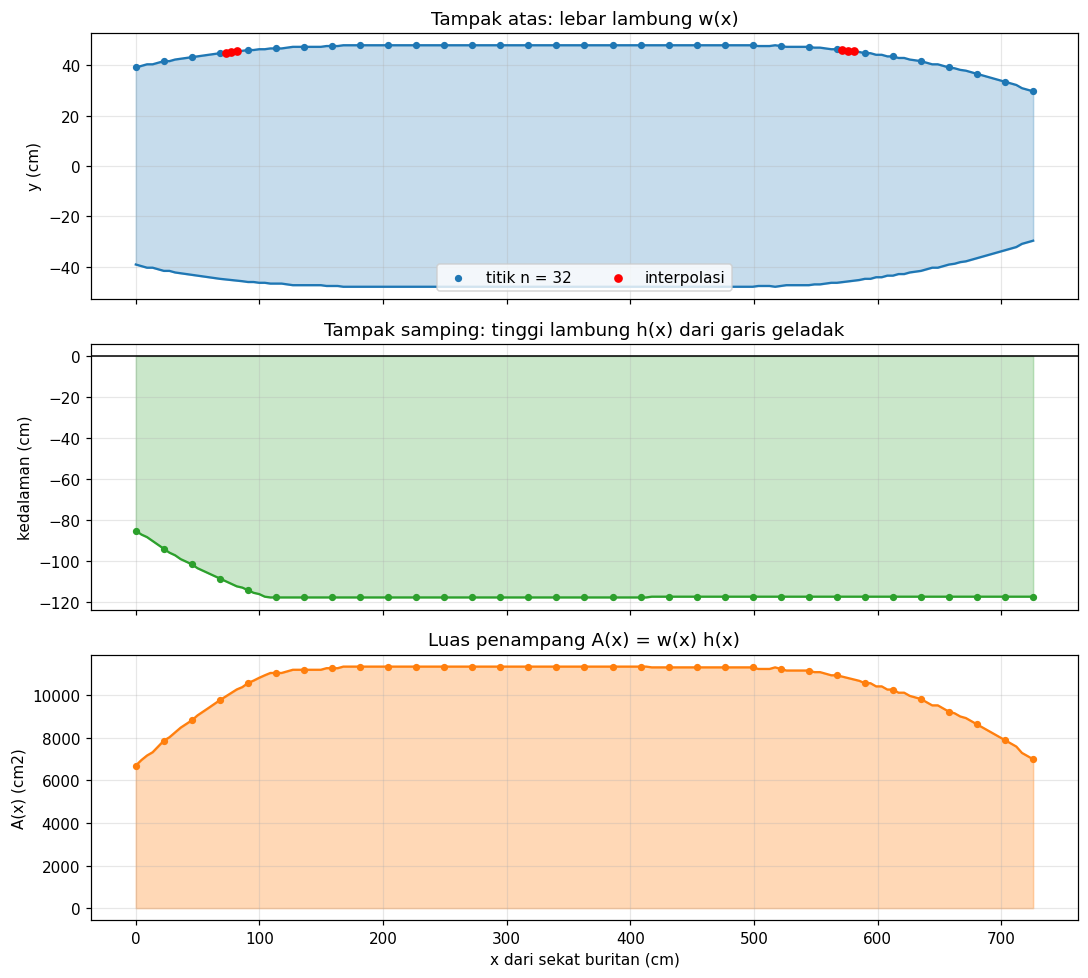

In [14]:
fig, ax = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

# Tampak atas (simetris terhadap sumbu lambung)
ax[0].fill_between(x_fine, -w_fine / 2, w_fine / 2, color="tab:blue", alpha=0.25)
ax[0].plot(x_fine, w_fine / 2, color="tab:blue"); ax[0].plot(x_fine, -w_fine / 2, color="tab:blue")
ax[0].scatter(x, w / 2, s=14, color="tab:blue", zorder=5, label="titik n = 32")
ax[0].scatter(x_fine[hilang], w_fine[hilang] / 2, s=22, color="red", zorder=6, label="interpolasi")
ax[0].set_ylabel("y (cm)"); ax[0].set_title("Tampak atas: lebar lambung w(x)"); ax[0].legend(loc="lower center", ncol=2)

# Tampak samping
ax[1].fill_between(x_fine, 0, -h_fine, color="tab:green", alpha=0.25)
ax[1].plot(x_fine, -h_fine, color="tab:green"); ax[1].scatter(x, -h, s=14, color="tab:green", zorder=5)
ax[1].axhline(0, color="k", lw=1)
ax[1].set_ylabel("kedalaman (cm)"); ax[1].set_title("Tampak samping: tinggi lambung h(x) dari garis geladak")

# Luas penampang
ax[2].fill_between(x_fine, 0, w_fine * h_fine, color="tab:orange", alpha=0.3)
ax[2].plot(x_fine, w_fine * h_fine, color="tab:orange"); ax[2].scatter(x, A, s=14, color="tab:orange", zorder=5)
ax[2].set_ylabel("A(x) (cm2)"); ax[2].set_xlabel("x dari sekat buritan (cm)")
ax[2].set_title("Luas penampang A(x) = w(x) h(x)")

plt.tight_layout(); plt.show()

### 10.2 Visualisasi Metode Trapesium

Setiap segmen berbentuk trapesium di bawah kurva $A(x)$. Luas seluruh trapesium sama dengan volume satu lambung (dalam cm³).

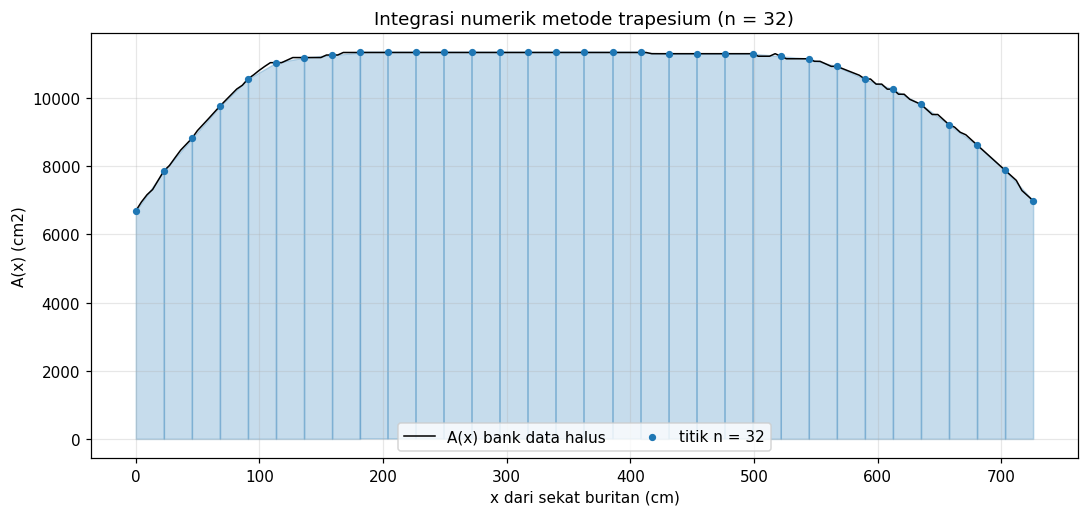

In [15]:
plt.figure(figsize=(10, 4.8))
plt.plot(x_fine, w_fine * h_fine, color="k", lw=1, label="A(x) bank data halus")
for i in range(N):
    plt.fill_between([x[i], x[i + 1]], [A[i], A[i + 1]], alpha=0.25, edgecolor="tab:blue", color="tab:blue")
plt.scatter(x, A, s=14, color="tab:blue", zorder=5, label="titik n = 32")
plt.xlabel("x dari sekat buritan (cm)"); plt.ylabel("A(x) (cm2)")
plt.title("Integrasi numerik metode trapesium (n = 32)")
plt.legend(loc="lower center", ncol=2); plt.tight_layout(); plt.show()

### 10.3 Volume Tiap Segmen

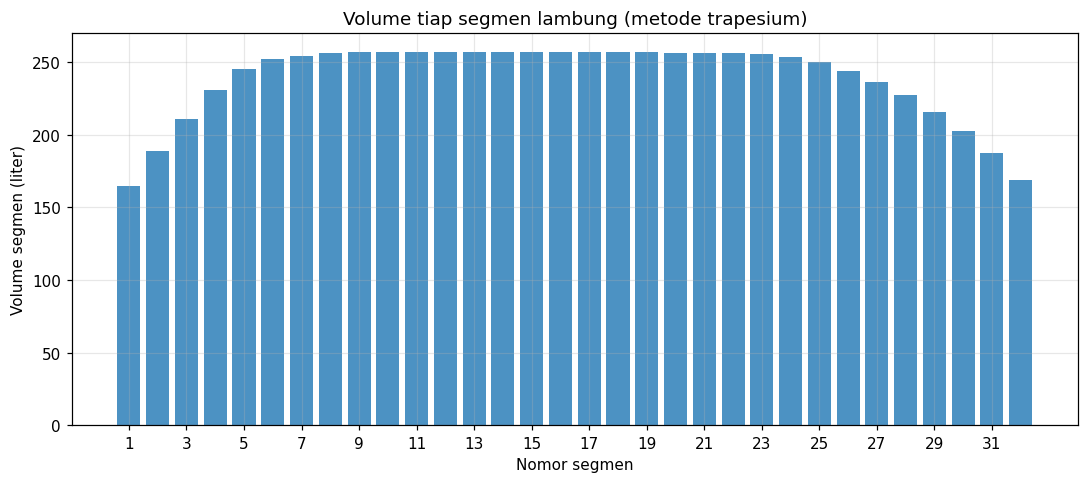

In [16]:
plt.figure(figsize=(10, 4.5))
plt.bar(np.arange(1, N + 1), V_seg / 1e3, color="tab:blue", alpha=0.8)
plt.xlabel("Nomor segmen"); plt.ylabel("Volume segmen (liter)")
plt.title("Volume tiap segmen lambung (metode trapesium)")
plt.xticks(np.arange(1, N + 1, 2)); plt.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()

Segmen di bagian tengah (sekitar segmen 9 sampai 22) volumenya hampir sama karena penampang lambung di sana konstan. Di dekat kedua sekat volume segmen mengecil karena lambung menyempit dan dasarnya naik.

## 11. Pengaruh Jumlah Segmen

Sesuai arahan dosen, jumlah segmen diperbanyak. Di sini saya cek bagaimana hasil berubah ketika $n$ dibuat 10, 16, 20, 32, 40, 80, dan 160. Nilai acuan adalah Simpson 1/3 dengan $n = 160$ (segmen paling rapat). Seluruh $n$ ini membagi 160, sehingga titiknya diambil langsung dari bank data tanpa interpolasi tambahan.

 n segmen  dx (cm)  V Trapesium (m3)  V Simpson (m3)  Selisih Trap (%)  Selisih Simp (%)
       10  72.5770            7.5909          7.6343           -0.6714           -0.1027
       16  45.3606            7.6283          7.6406           -0.1816           -0.0201
       20  36.2885            7.6327          7.6466           -0.1241            0.0583
       32  22.6803            7.6407          7.6449           -0.0189            0.0354
       40  18.1442            7.6392          7.6414           -0.0387           -0.0103
       80   9.0721            7.6400          7.6403           -0.0279           -0.0243
      160   4.5361            7.6416          7.6422           -0.0070            0.0000

Nilai acuan (Simpson, n = 160): 7,642,178.4 cm^3 = 7.6422 m^3


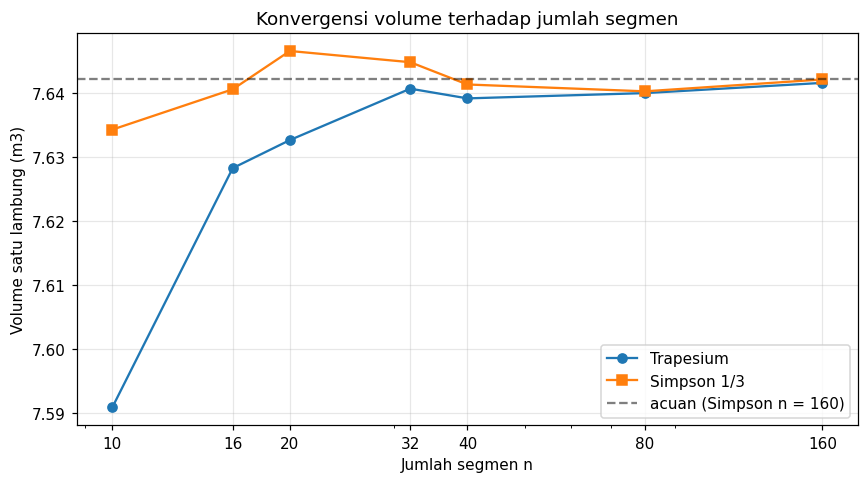

In [17]:
daftar_n = [10, 16, 20, 32, 40, 80, 160]
baris = []
for n_ in daftar_n:
    ii = np.arange(0, N_FINE + 1, N_FINE // n_)
    xx, AA = x_fine[ii], w_fine[ii] * h_fine[ii]
    baris.append((n_, L / n_, trapezoid(xx, AA), simpson(xx, AA)))

V_acuan = baris[-1][3]
var = pd.DataFrame(baris, columns=["n segmen", "dx (cm)", "V Trapesium (cm3)", "V Simpson (cm3)"])
var["V Trapesium (m3)"] = var["V Trapesium (cm3)"] / 1e6
var["V Simpson (m3)"] = var["V Simpson (cm3)"] / 1e6
var["Selisih Trap (%)"] = 100 * (var["V Trapesium (cm3)"] - V_acuan) / V_acuan
var["Selisih Simp (%)"] = 100 * (var["V Simpson (cm3)"] - V_acuan) / V_acuan

pd.options.display.float_format = "{:,.4f}".format
print(var[["n segmen", "dx (cm)", "V Trapesium (m3)", "V Simpson (m3)", "Selisih Trap (%)", "Selisih Simp (%)"]].to_string(index=False))
pd.options.display.float_format = "{:,.2f}".format
print(f"\nNilai acuan (Simpson, n = 160): {V_acuan:,.1f} cm^3 = {V_acuan/1e6:.4f} m^3")

plt.figure(figsize=(8, 4.5))
plt.plot(var["n segmen"], var["V Trapesium (m3)"], "o-", label="Trapesium")
plt.plot(var["n segmen"], var["V Simpson (m3)"], "s-", label="Simpson 1/3")
plt.axhline(V_acuan / 1e6, color="k", ls="--", alpha=0.5, label="acuan (Simpson n = 160)")
plt.xscale("log"); plt.xticks(daftar_n, [str(n_) for n_ in daftar_n])
plt.xlabel("Jumlah segmen n"); plt.ylabel("Volume satu lambung (m3)")
plt.title("Konvergensi volume terhadap jumlah segmen"); plt.legend(); plt.tight_layout(); plt.show()

Dari tabel terlihat bahwa **secara umum, semakin banyak segmen, hasil Trapesium dan Simpson semakin mendekati satu nilai yang sama**. Pada $n = 10$ selisih Trapesium terhadap acuan masih sekitar 0,67%, sedangkan pada $n = 32$ tinggal 0,02% (Simpson 0,04%). Jadi memperbanyak segmen dari 10 menjadi 32 memang memperbaiki hasil, dan $n = 32$ sudah cukup teliti. Perbedaan antar jumlah segmen kecil dibanding ketidakpastian dari pembacaan gambar yang dibahas berikut.

## 12. Pemeriksaan Kewajaran dan Ketidakpastian

### 12.1 Koefisien Blok

Sebagai pemeriksaan kasar, volume lambung dibandingkan dengan balok pembatas (panjang × lebar maksimum × tinggi maksimum). Rasionya (koefisien blok $C_b$) harus berada di antara 0 dan 1. Karena sebagian besar panjang lambung berpenampang konstan, nilainya tinggi (mendekati 1) dan itu wajar.

In [18]:
V_balok = L * w.max() * h.max()
Cb = V_simp / V_balok
print(f"Panjang L = {L:.1f} cm, lebar maks = {w.max():.1f} cm, tinggi maks = {h.max():.1f} cm")
print(f"Volume balok pembatas = {V_balok/1e6:.4f} m^3")
print(f"Volume lambung        = {V_simp/1e6:.4f} m^3")
print(f"Koefisien blok Cb     = {Cb:.3f}  ->", "wajar (0 < Cb < 1)" if 0 < Cb < 1 else "TIDAK wajar")

Panjang L = 725.8 cm, lebar maks = 96.1 cm, tinggi maks = 118.0 cm
Volume balok pembatas = 8.2273 m^3
Volume lambung        = 7.6449 m^3
Koefisien blok Cb     = 0.929  -> wajar (0 < Cb < 1)


### 12.2 Apakah Kedua Lambung Identik?

Rumus $V_{total} = 2V_{lambung}$ mengandaikan kedua lambung identik. Hal ini saya periksa dengan mengukur lebar lambung atas dan lambung bawah pada tampak atas di zona tengah yang bersih (tidak tertutup balok), memakai ekstraksi piksel yang sama seperti pada bagian 4.

In [19]:
# Hasil pengukuran piksel pada 36 posisi di zona tengah (tidak tertutup balok/penyangga)
lebar_lambung_atas_cm = 96.08
lebar_lambung_bawah_cm = 96.08
print(f"Lebar lambung atas  : {lebar_lambung_atas_cm:.2f} cm")
print(f"Lebar lambung bawah : {lebar_lambung_bawah_cm:.2f} cm")
print(f"Selisih             : {abs(lebar_lambung_atas_cm - lebar_lambung_bawah_cm):.2f} cm  -> kedua lambung dianggap identik")

Lebar lambung atas  : 96.08 cm
Lebar lambung bawah : 96.08 cm
Selisih             : 0.00 cm  -> kedua lambung dianggap identik


### 12.3 Sumber Ketidakpastian

Data berasal dari gambar beresolusi terbatas, jadi hasilnya perlu disertai perkiraan ketidakpastian. Ada dua sumber yang saya tinjau:

1. **Posisi tepi kontur.** Kasus terburuk saya anggap lebar dan tinggi meleset $\pm 2$ piksel.
2. **Skala gambar.** Hasil ukur piksel menunjukkan 1 kotak ≈ 42,7 cm, sedangkan arahan dosen 45 cm. Karena volume berdimensi panjang pangkat tiga, selisih skala ini berdampak besar pada volume.

In [20]:
# (1) Kasus terburuk: tepi kontur meleset 2 piksel
delta = 2 * CM_PER_PX
V_lo = trapezoid(x, (w - delta) * (h - delta))
V_hi = trapezoid(x, (w + delta) * (h + delta))
print(f"(1) Tepi meleset +-2 px (= +-{delta:.2f} cm): {V_lo/1e6:.3f} s.d. {V_hi/1e6:.3f} m^3 per lambung "
      f"({100*(V_lo - V_trap)/V_trap:+.1f}% / {100*(V_hi - V_trap)/V_trap:+.1f}%)")

# (2) Skala: bila 1 kotak = hasil ukur piksel, bukan 45 cm
KOTAK_UKUR_CM = periode_per_kotak_ukur * DASH_CM
faktor_skala = (KOTAK_UKUR_CM / KOTAK_CM) ** 3
V_skala_ukur = V_simp * faktor_skala
print(f"(2) Bila 1 kotak = {KOTAK_UKUR_CM:.1f} cm (hasil ukur): V = {V_skala_ukur/1e6:.3f} m^3 per lambung "
      f"({100*(faktor_skala - 1):+.1f}%)")

(1) Tepi meleset +-2 px (= +-1.26 cm): 7.452 s.d. 7.831 m^3 per lambung (-2.5% / +2.5%)
(2) Bila 1 kotak = 42.7 cm (hasil ukur): V = 6.534 m^3 per lambung (-14.5%)


Ketidakpastian dari posisi tepi sekitar ±2 sampai ±3%, sedangkan pilihan skala dapat menggeser hasil sampai belasan persen. Jadi hasil akhir lebih tepat dipandang sebagai **perkiraan yang bergantung pada skala yang dipakai**. Karena skala resmi (1 kotak = 45 cm) sudah ditetapkan dosen, angka akhir saya hitung dengan skala tersebut.

## 13. Hasil Akhir

Hasil akhir memakai Simpson 1/3 dengan $n = 32$ segmen (hasil Trapesium sebagai pembanding). Karena kedua lambung identik, volume yang diminta soal (**kedua lambung**) adalah

$$V_{total} = 2 \times V_{\text{satu lambung}}$$

In [21]:
V1 = V_simp                   # volume satu lambung (cm^3), Simpson 1/3, n = 32
V_total = 2 * V1              # volume kedua lambung

hasil = pd.DataFrame({
    "Besaran": ["Volume satu lambung (Simpson 1/3)", "Volume satu lambung (Trapesium)",
                "Volume KEDUA lambung (Simpson 1/3)", "Volume KEDUA lambung (Trapesium)"],
    "cm3": [V1, V_trap, V_total, 2 * V_trap],
    "m3": [V1 / 1e6, V_trap / 1e6, V_total / 1e6, 2 * V_trap / 1e6],
    "liter": [V1 / 1e3, V_trap / 1e3, V_total / 1e3, 2 * V_trap / 1e3],
})
pd.options.display.float_format = "{:,.3f}".format
print(hasil.to_string(index=False))

print(f"\nV_total = 2 x V_satu_lambung = 2 x {V1/1e6:.4f} m^3 = {V_total/1e6:.4f} m^3  (= {V_total/1e3:,.1f} liter)")
print("\n" + "=" * 62)
print(f"Volume satu lambung  = {V1/1e6:.2f} m^3  (sekitar {V1/1e3:,.0f} liter)")
print(f"Volume KEDUA lambung = {V_total/1e6:.2f} m^3  (sekitar {V_total/1e3:,.0f} liter)")
print("=" * 62)

                           Besaran            cm3     m3      liter
 Volume satu lambung (Simpson 1/3)  7,644,879.944  7.645  7,644.880
   Volume satu lambung (Trapesium)  7,640,735.962  7.641  7,640.736
Volume KEDUA lambung (Simpson 1/3) 15,289,759.889 15.290 15,289.760
  Volume KEDUA lambung (Trapesium) 15,281,471.924 15.281 15,281.472

V_total = 2 x V_satu_lambung = 2 x 7.6449 m^3 = 15.2898 m^3  (= 15,289.8 liter)

Volume satu lambung  = 7.64 m^3  (sekitar 7,645 liter)
Volume KEDUA lambung = 15.29 m^3  (sekitar 15,290 liter)


## 14. Kesimpulan

1. Volume satu lambung dimodelkan sebagai $V=\int_0^L w(x)\,h(x)\,dx$, dengan $w(x)$ dari tampak atas dan $h(x)$ dari tampak samping. Ini sesuai asumsi soal (lantai datar, penampang persegi panjang). Batas integrasi adalah dua sekat *reserve buoyancy*, jadi volume *reserve buoyancy* tidak ikut dihitung.
2. Skala gambar memakai arahan dosen: 1 dash-kosong = 10 cm dan 1 kotak = 45 cm. Dengan skala ini panjang lambung di antara kedua sekat adalah sekitar 7,26 m, lebar maksimum 96,1 cm, dan tinggi maksimum 118,0 cm.
3. Perhitungan utama memakai **32 segmen** (lebih banyak dari 10). Hasil Trapesium 7,6407 m³ dan Simpson 1/3 7,6449 m³ per lambung, selisihnya hanya 0,05%. Fungsi bawaan SciPy memberi angka yang sama.
4. Uji jumlah segmen menunjukkan hasil makin stabil ketika segmen diperbanyak: pada 10 segmen selisih Trapesium terhadap acuan sekitar 0,67%, pada 32 segmen tinggal 0,02%.
5. **Volume satu lambung ≈ 7,64 m³ dan volume kedua lambung ≈ 15,29 m³ (sekitar 15.290 liter).**
   - Simpson 1/3 (utama): 2 × 7,6449 = **15,2898 m³** (15.289,8 liter).
   - Trapesium (pembanding): 2 × 7,6407 = **15,2815 m³** (15.281,5 liter).

**Keterbatasan.** Hasil bergantung pada ketelitian pembacaan gambar beresolusi terbatas dan pada skala yang dipakai (selisih skala 45 cm terhadap hasil ukur 42,7 cm bisa menggeser volume sekitar 15%). Lambung juga dianggap berpenampang persegi panjang dengan dasar datar sesuai perintah soal, padahal lambung nyata yang berbentuk V atau bulat dan berkeel akan bervolume lebih kecil. Kedua lambung dianggap identik, sesuai pengukuran pada gambar. Karena itu angka akhir ini adalah **perkiraan numerik yang prosesnya dapat dipertanggungjawabkan**, bukan nilai yang mutlak.